# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| Æ | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Ø | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Å | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| Q | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



---

## Preamble

In [1]:
# Relevant imports for the project
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

party_mapping = {
    "Socialdemokratiet": "A",
    "Radikale Venstre": "B",
    "Det Konservative Folkeparti": "C",
    "Nye Borgerlige": "D",
    "Socialistisk Folkeparti": "F",
    "Liberal Alliance": "I",
    "Kristendemokraterne": "K",
    "Moderaterne": "M",
    "Dansk Folkeparti": "O",
    "Danmarksdemokraterne": "Æ",
    "Venstre": "V",
    "Enhedslisten": "Ø",
    "Alternativet": "Å",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "Q"
}

party_colors = {
    "Socialdemokratiet": "#B22222",
    "Radikale Venstre": "#6A5ACD",
    "Det Konservative Folkeparti": "#9ACD32",
    "Nye Borgerlige": "#2F4F4F",
    "Socialistisk Folkeparti": "#FF1493",
    "Liberal Alliance": "#00CED1",
    "Kristendemokraterne": "#D3D3D3",
    "Moderaterne": "#800080",
    "Dansk Folkeparti": "#DAA520",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#008000",
    "Venstre": "#00008B",
    "Danmarksdemokraterne": "#87CEEB",
    "Enhedslisten": "#D2691E",
    "Alternativet": "#228B22"
}

## Loading & Inspecting Data

In [2]:
df = alldata = pd.read_excel('alldata.xlsx')
drdata = pd.read_excel('drdata.xlsx')
drq = pd.read_excel('drq.xlsx')
tv2data = pd.read_excel('tv2data.xlsx')
tv2q = pd.read_excel('tv2q.xlsx')
electeddata = pd.read_excel('electeddata.xlsx')

### DR Questions

Inspecting the questions from the DR television network immediately revealed that *Info* and *QuestionListData* columns both contain *NaN* values. This could pose a problem in further use of data so we would need to investigate the total amount of missing data and either delete rows with *NaN* values or the columns as a whole. However, considering the fact there the number of questions is low (25), removing the columns would be a more propriete approach.

In [3]:
drq.head()

,ID,Title,Question,Info,ArgumentFor,ArgumentAgainst,WordMerger,ID_CandidateQuestionType,Rule,QuestionListData
0,530,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...,NaN,Den kollektive trafik bør være billig og tilgæ...,Det er dyrt for statskassen at opretholde drif...,0,1,FT,NaN
1,531,ARBEJDSMARKED OG ØKONOMI,Der skal indføres en særlig skat på de allerhø...,NaN,Historisk rammer kriser de fattigste hårdest. ...,Det danske samfund er et af de mest lige samfu...,0,1,FT,NaN
2,533,RET OG STRAF,Kriminalitet begået i udsatte boligområder ska...,NaN,Den mest effektive måde at stoppe bandekrimina...,"Det er urimeligt, at den samme forbrydelse ska...",0,1,FT,NaN
3,534,EU OG UDENRIGS,På sigt skal Danmark meldes ud af EU,NaN,"Så længe Danmark er medlem af EU, kan flertall...",Danmark er bedst tjent med at være en del af E...,0,1,FT,NaN
4,535,EU OG UDENRIGS,"Det er fornuftigt, at Danmark i de kommende år...",NaN,Ruslands angreb på Ukraine har ændret alting o...,Vi er medlemmer af Nato og har i forvejen et s...,0,1,FT,NaN


In [4]:
drq.shape

(25, 10)

### DR Answers

Initially, we wanted to understand the way, the answers are stored within the dataset. 

As seen below, the DR television network stores the information about the candidate in a form of their name, name of the party they belong to, and answers to each question based on the *ID*.

In [5]:
display(drdata.columns)

Index(['530', '531', '533', '534', '535', '537', '538', '540', '541', '543',
       '544', '545', '546', '547', '548', '550', '551', '552', '553', '555',
       '556', '557', '559', '561', '563', 'navn', 'parti'],
      dtype='object')

In [6]:
drdata.head()

,530,531,533,534,535,537,538,540,541,543,...,552,553,555,556,557,559,561,563,navn,parti
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,-2,2,2,1,2,2,-2,Lars Philipsen Prahm,Moderaterne
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,1,1,-1,-2,1,2,1,2,Karsten Hønge,Socialistisk Folkeparti
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,2,-1,-2,-1,1,2,2,2,Martin Kelleher-Petersen,Alternativet
3,2,1,-2,-1,1,1,1,1,1,-2,...,2,1,2,-2,2,2,2,2,Nicklas Gjedsig Larsen,Alternativet
4,1,1,-2,2,-2,1,-2,1,2,-2,...,2,-2,-2,-1,1,-2,-1,-2,Tom Gillesberg,Løsgænger


### TV2 Questions

The questions of TV2 were formed in slightly different way. There is 74 questions in total, however, only 24 of those are asked to all candidates, not depending on the area/region they live in. These 24 questions are then included in the *"alldata"* dataset.

In [7]:
tv2q.head()

,id,type,header,question,depends
0,bornholm-1,rate,Bornholms Storkreds,Med særligt attraktive vilkår bør staten sikre...,{'selectedArea': 'bornholms storkreds'}
1,bornholm-2,rate,Bornholms Storkreds,"Staten bør sørge for, at flytrafikken til og f...",{'selectedArea': 'bornholms storkreds'}
2,bornholm-3,rate,Bornholms Storkreds,Der skal sættes flere penge af til Forsvarets ...,{'selectedArea': 'bornholms storkreds'}
3,bornholm-4,rate,Bornholms Storkreds,Det skal være lettere at hente udenlandsk arbe...,{'selectedArea': 'bornholms storkreds'}
4,bornholm-5,rate,Bornholms Storkreds,Beslutningen om at etablere en naturnationalpa...,{'selectedArea': 'bornholms storkreds'}


In [8]:
tv2q.tail()

,id,type,header,question,depends
69,10b,rate,Socialområdet,"Den såkaldte Arne-pension, der giver mulighed ...",NaN
70,11a,rate,Mink-sagen,Der har været alt for meget fokus på Mette Fre...,NaN
71,11b,rate,Mink-sagen,"Det bør undersøges, om Mette Frederiksen kan s...",NaN
72,12a,rate,Coronavirus,"Hvis coronasmitten stiger markant til vinter, ...",NaN
73,12b,rate,Coronavirus,"Hvis coronasmitten stiger markant til vinter, ...",NaN


In [9]:
tv2q.shape

(74, 5)

### TV2 Responses

Compared to the DR channel, TV2 stored an additional information about each cadidate. These information being the region they reside at, and their age.

In [10]:
display(tv2data.columns)

Index(['1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b',
       '7a', '7b', '8a', '8b', '9a', '9b', '10a', '10b', '11a', '11b', '12a',
       '12b', 'parti', 'navn', 'storkreds', 'alder'],
      dtype='object')

In [11]:
tv2data.head()

,1a,1b,2a,2b,3a,3b,4a,4b,5a,5b,...,10a,10b,11a,11b,12a,12b,parti,navn,storkreds,alder
0,0,1,1,1,1,-1,0,1,0,0,...,0,2,-1,2,0,0,Venstre,Birthe Tindbæk Bredo,Bornholms Storkreds,63
1,-1,1,0,-1,2,-2,-1,-1,-2,1,...,1,-1,-1,2,1,-1,Venstre,Julie Pauch Nymark,Bornholms Storkreds,27
2,-2,0,0,1,1,-1,0,1,-1,1,...,1,1,-2,2,1,1,Venstre,Peter Juel-Jensen,Bornholms Storkreds,56
3,-2,-1,2,2,2,-2,0,-1,-2,1,...,1,-1,-2,2,2,-2,Dansk Folkeparti,Mette Sode Hansen,Bornholms Storkreds,42
4,-2,-1,1,1,2,-2,1,0,-1,1,...,2,1,-1,2,0,1,Dansk Folkeparti,René Danielsson,Bornholms Storkreds,35


### Combined Responses

The *"alldata"* dataset consists of the responses from both TV stations merged together. Such a dataset is useful for overall analysis with less of a depth into understanding of each question or candidate.

In [12]:
display(alldata.columns)

Index(['530', '531', '533', '534', '535', '537', '538', '540', '541', '543',
       '544', '545', '546', '547', '548', '550', '551', '552', '553', '555',
       '556', '557', '559', '561', '563', 'navn', 'parti', '1a', '1b', '2a',
       '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b', '7a', '7b', '8a',
       '8b', '9a', '9b', '10a', '10b', '11a', '11b', '12a', '12b', 'storkreds',
       'alder'],
      dtype='object')

In [13]:
alldata.head()

,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


In [14]:
print(alldata[alldata.isna().any(axis=1)])

Empty DataFrame
Columns: [530, 531, 533, 534, 535, 537, 538, 540, 541, 543, 544, 545, 546, 547, 548, 550, 551, 552, 553, 555, 556, 557, 559, 561, 563, navn, parti, 1a, 1b, 2a, 2b, 3a, 3b, 4a, 4b, 5a, 5b, 6a, 6b, 7a, 7b, 8a, 8b, 9a, 9b, 10a, 10b, 11a, 11b, 12a, 12b, storkreds, alder]
Index: []

[0 rows x 53 columns]


### Results of elected candidates

If needed, this dataset could be removed and replaced by inserting a new column into the *"alldata"* with either 1 as elected or 0 for non-elected candidates.

In [15]:
electeddata.head()

,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
1,2,2,-2,-2,-2,-2,2,2,2,-2,...,-2,0,-2,2,1,1,0,-2,Østjyllands Storkreds,58
2,2,2,-2,-1,-1,-1,1,-2,2,-2,...,-2,0,-1,2,0,-2,-1,1,Østjyllands Storkreds,30
3,-1,-1,2,-1,2,-1,-2,1,-2,1,...,-1,-1,0,2,-2,2,0,0,Østjyllands Storkreds,53
4,-1,-1,1,-2,2,1,-2,1,-2,1,...,-1,0,1,1,-2,2,1,-1,Østjyllands Storkreds,46


## Preparing Data

We have used the mapping of parties which was shared with us in the beginning of this document to clean the data from any other unexpected party names, or candidates non-affiliated with any party (*Løsgænger*). Additioanlly, we have added the party letters to help with matching of our graphs with the initial election results graph.

Total amount of X rows was removed as result.

In [16]:
alldata_cleaned = alldata[alldata['parti'].isin(party_mapping.keys())].copy()

alldata_cleaned['parti_letter'] = alldata_cleaned['parti'].map(party_mapping)

alldata_cleaned = alldata_cleaned[alldata_cleaned['alder'] > 0]

print(f'Shape of Original Data: {alldata.shape}')
print(f'Shape of Cleaned Data: {alldata_cleaned.shape}')

Shape of Original Data: (867, 53)
Shape of Cleaned Data: (848, 54)


## Analysis of Candidate Test 2022 

### Candidates per Party

In [17]:
party_counts = alldata_cleaned["parti"].value_counts()
party_counts

parti
Det Konservative Folkeparti                    94
Socialdemokratiet                              85
Venstre                                        84
Enhedslisten                                   71
Socialistisk Folkeparti                        69
Liberal Alliance                               68
Radikale Venstre                               67
Alternativet                                   65
Nye Borgerlige                                 50
Dansk Folkeparti                               49
Moderaterne                                    42
Kristendemokraterne                            41
Danmarksdemokraterne                           37
Frie Grønne, Danmarks Nye Venstrefløjsparti    26
Name: count, dtype: int64

###  Age of the candidates grouped by parties

From the analysis below, we see that Danmarksdemokraterne has the highest average candidate age (51 years), while Frie Grønne has the lowest (34 years).

Comparing this to the election results, there is no clear correlation between average age and a party's success. However, the youngest party finishing second to last could suggest that experience plays a role in political performance.

In [18]:
df_age_party = alldata_cleaned[['alder', 'parti', 'parti_letter']].dropna()

grouped_average = df_age_party.groupby(['parti', 'parti_letter']).mean().reset_index()

sorted_ages = grouped_average.sort_values('parti_letter', ascending=True)

fig = px.bar(sorted_ages, x='parti', y='alder', 
             title='Average Age of Candidates by Party',
             labels={'parti': 'Party', 'alder': 'Average Age'},
             color='parti',
             color_discrete_map=party_colors,
             height=600, width=1000)

fig.update_traces(hovertemplate=None)
fig.update_layout(showlegend=False)
fig.show()

In [19]:
oldest_candidate = alldata_cleaned.loc[alldata_cleaned['alder'].idxmax(), ['alder', 'navn', 'parti']]
youngest_candidate = alldata_cleaned.loc[alldata_cleaned['alder'].idxmin(), ['alder', 'navn', 'parti']]

print(f"Age, Name, and Party of the oldest candidate: {oldest_candidate['alder']}, {oldest_candidate['navn']}, {oldest_candidate['parti']}")
print(f"Age, Name, and Party of the youngest candidate: {youngest_candidate['alder']}, {youngest_candidate['navn']}, {youngest_candidate['parti']}")
print(f"Average age of all candidates: {alldata_cleaned['alder'].mean()}")

Age, Name, and Party of the oldest candidate: 79, Ulla Sandbæk, Alternativet
Age, Name, and Party of the youngest candidate: 18, Sinus Kremmer, Liberal Alliance
Average age of all candidates: 44.68985849056604


### An overview of the most "confident" candidates

> *NOTE: Those with the highest proportion of "strongly agree" or "strongly disagree" responses are deemed to be the "confident" ones.*

For this analysis, we have decided to use the original dataset since the "cleaned" version removed candidates without association to any party which is not relevant for this part of analysis. 

The results reveal that several parties have highly confident candidates who ranked in the TOP 10. Sarah Nørris and Søren Vanting share the first place, each with 49 responses marked as "strongly agree" or "strongly disagree."

Additionally, the diverse ages of the candidates in the TOP 10 suggest that confidence is not strongly linked to age.

In [20]:
dfQuestionsWithName = alldata.drop(columns=['storkreds'])

dfQuestionsWithName["confident_answers"] = dfQuestionsWithName.isin([-2,2]).sum(axis=1)

print(dfQuestionsWithName[["navn", "confident_answers", 'alder', 'parti']].sort_values("confident_answers", ascending=False).head(10))

                    navn  confident_answers  alder  \
505         Sarah Nørris                 49     43   
88         Søren Vanting                 49     50   
559  Kim Andkjær Doberck                 44     43   
152           Rashid Ali                 43     38   
44     Mohamed Abdikarim                 43     33   
503          Jan Filbært                 42     57   
151     Elise Bjerkrheim                 42     48   
284           John Bjerg                 42     58   
359       Frank Sørensen                 42     58   
437  Lone Vase Langballe                 42     52   

                                           parti  
505                                 Enhedslisten  
88                   Det Konservative Folkeparti  
559                               Nye Borgerlige  
152  Frie Grønne, Danmarks Nye Venstrefløjsparti  
44   Frie Grønne, Danmarks Nye Venstrefløjsparti  
503                                 Enhedslisten  
151  Frie Grønne, Danmarks Nye Venstrefløjsparti

In [21]:
print(alldata[alldata.navn=='Sarah Nørris'])

     530  531  533  534  535  537  538  540  541  543  ...  9a  9b  10a  10b  \
505    2    2   -2    2   -2   -2    2   -2    2   -2  ...  -2  -2   -2    2   

     11a  11b  12a  12b              storkreds  alder  
505    2   -2   -2   -2  Sydjyllands Storkreds     43  

[1 rows x 53 columns]


 ### Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.

#### Inter-Party Differences

Inter-party differences measure how much parties differ from one another in their responses. As seen from the graph below, the *Nye Borgerlige* and *Enhedslisten* were two parties which differ the most in their answers.

In [22]:
# Calculating the mean responses for each party.
inter_party_means = alldata_cleaned.drop(columns=['alder', 'storkreds', 'navn', 'parti_letter']).groupby('parti').mean()

# Finding the absolute deviation of each party’s mean from the overall mean.
inter_party_differences = abs(inter_party_means - inter_party_means.mean())

In [23]:
inter_party_differences_df = inter_party_differences.mean(axis=1).reset_index() # similar to unstack.
inter_party_differences_df.columns = ['parti', 'mean']

fig = px.bar(
    inter_party_differences_df, x='parti', y='mean',
    title='Average Inter-Party Differences',
    labels={'parti': 'Party', 'mean': 'Mean Difference'},
    color='parti',
    color_discrete_map=party_colors,
    height=600, width=1000
)

fig.update_traces()
fig.update_layout(showlegend=False)
fig.show()

This heatmap shows where the parties differ the most for each question.

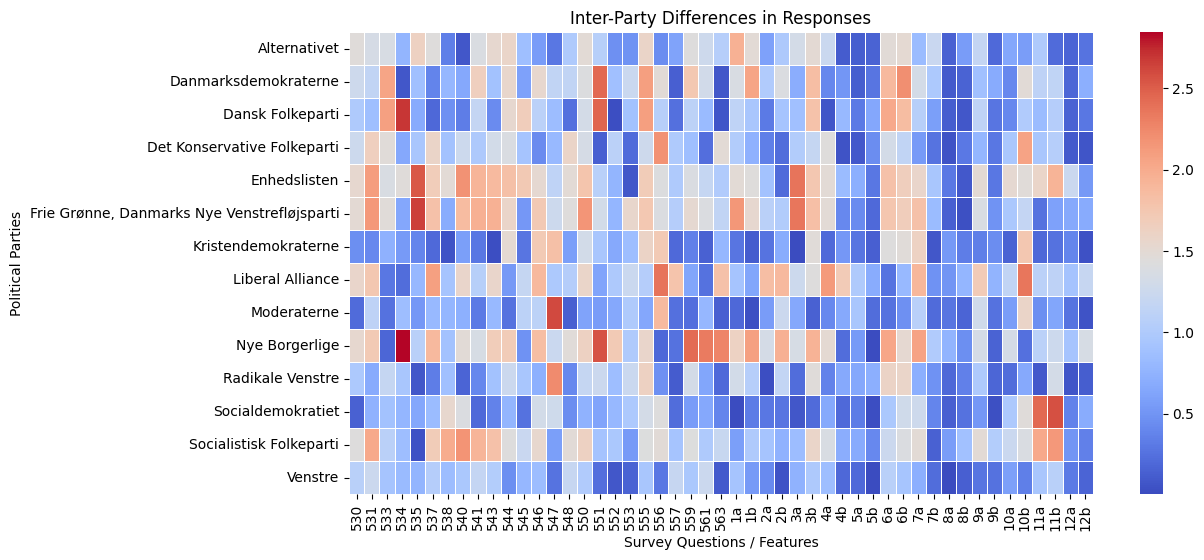

In [24]:
plt.figure(figsize=(12, 6))
sns.heatmap(inter_party_differences, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Inter-Party Differences in Responses")
plt.xlabel("Survey Questions / Features")
plt.ylabel("Political Parties")
plt.show()

In [25]:
print('Parties with most inter-party differences')
variance_between_parties = inter_party_differences.sum(axis=1).sort_values(ascending=False)
variance_between_parties.head()

Parties with most inter-party differences


parti
Nye Borgerlige                                 65.445514
Enhedslisten                                   65.114605
Frie Grønne, Danmarks Nye Venstrefløjsparti    62.243410
Liberal Alliance                               58.292663
Socialistisk Folkeparti                        57.448074
dtype: float64

#### Intra-Party Differences

Intra-party variance measures how much disagreement exists *within* each party. The biggest variance can be found within *Kristendemokraterne* party with the most disagreements being on quetion from DR station with ID 552.

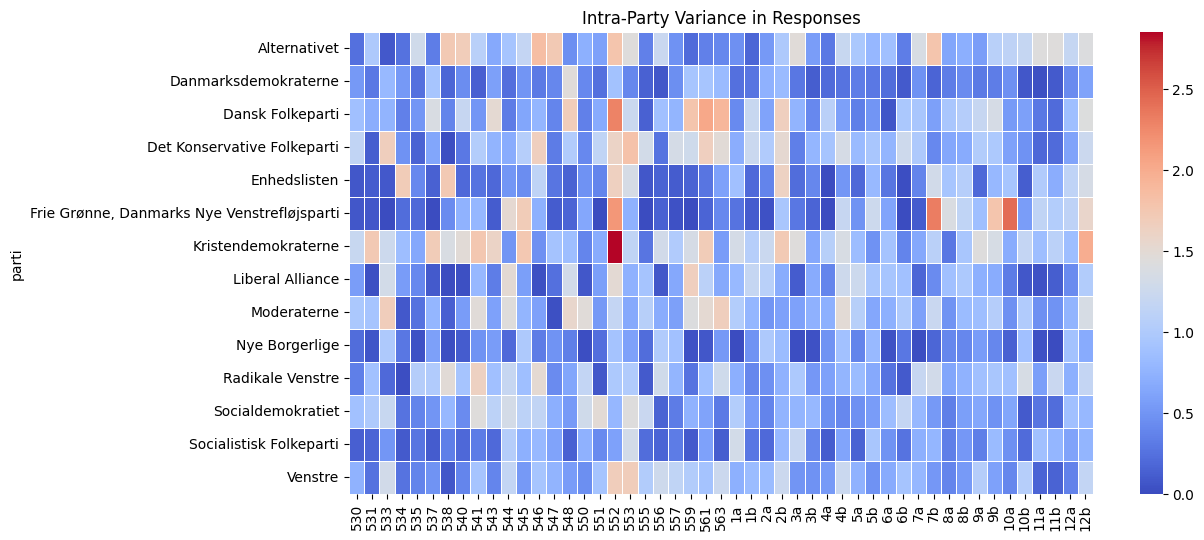

In [26]:
intra_party_variance = alldata_cleaned.drop(columns=['alder', 'storkreds', 'navn', 'parti_letter']).groupby('parti').var()

plt.figure(figsize=(12, 6))
sns.heatmap(intra_party_variance, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Intra-Party Variance in Responses")

plt.show()

In [27]:
print('Parties with most internal differences')
variance_per_party = intra_party_variance.sum(axis=1).sort_values(ascending=False)
variance_per_party.head()

Parties with most internal differences


parti
Kristendemokraterne            54.154878
Alternativet                   44.525481
Det Konservative Folkeparti    42.856326
Dansk Folkeparti               42.531463
Moderaterne                    41.904762
dtype: float64

### Classification models to predict candidates' party affiliations. 

> *Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.*

We have trained three models to help us classify "wrong" party candidates based on their answers. Out of these models, the **Random Forest** had the best accuracy of 92%. Using this model, we have displayed the **True** and **Predicted** parties for the tested data using the *Label Encoder*. 

We could not identify any clear patterns within the **Predicted** and **True** parties for the candidates other than that the model struggles to differentiate between parties with similar ideologies or positions:

- Right-wing parties (Venstre vs Det Konservative Folkeparti and Radikale Venstre)
- Left-wing parties (Frie Grønne, Danmarks Nye Venstrefløjsparti vs Enhedslisten)

##### Data Preprocessing

In [28]:
X = df.drop(columns=['navn', 'parti', 'storkreds', 'alder'])
y = df['parti']

# If you don’t use stratify=y, train_test_split will randomly divide the data,
# setting stratify=y will ensure that both the training and test sets maintain approximately the same 80/20 ratio.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Decision Tree

In [29]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

                                             precision    recall  f1-score   support

                               Alternativet       0.58      0.50      0.54        14
                       Danmarksdemokraterne       0.71      0.71      0.71         7
                           Dansk Folkeparti       0.80      0.80      0.80        10
                Det Konservative Folkeparti       0.88      0.75      0.81        20
                               Enhedslisten       0.93      0.93      0.93        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       0.60      0.60      0.60         5
                        Kristendemokraterne       0.50      0.25      0.33         8
                           Liberal Alliance       0.81      0.93      0.87        14
                                  Løsgænger       0.00      0.00      0.00         1
                                Moderaterne       0.73      1.00      0.84         8
                             Nye Borgerlige       0.64      0.90

c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



#### Random Forest

In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

                                             precision    recall  f1-score   support

                               Alternativet       0.87      0.93      0.90        14
                       Danmarksdemokraterne       1.00      1.00      1.00         7
                           Dansk Folkeparti       1.00      1.00      1.00        10
                Det Konservative Folkeparti       1.00      0.80      0.89        20
                               Enhedslisten       0.93      0.93      0.93        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       0.80      0.80      0.80         5
                        Kristendemokraterne       1.00      0.88      0.93         8
                           Liberal Alliance       0.82      1.00      0.90        14
                                  Løsgænger       0.00      0.00      0.00         1
                                Moderaterne       1.00      1.00      1.00         8
                             Nye Borgerlige       0.91      1.00

c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



### Gradient Boosted Tree

In [31]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print(classification_report(y_test, y_pred_gb))

                                             precision    recall  f1-score   support

                               Alternativet       0.75      0.86      0.80        14
                       Danmarksdemokraterne       1.00      0.71      0.83         7
                           Dansk Folkeparti       0.90      0.90      0.90        10
                Det Konservative Folkeparti       0.94      0.75      0.83        20
                               Enhedslisten       0.93      0.87      0.90        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       0.75      0.60      0.67         5
                        Kristendemokraterne       0.83      0.62      0.71         8
                           Liberal Alliance       0.78      1.00      0.88        14
                                  Løsgænger       0.00      0.00      0.00         1
                                Moderaterne       0.89      1.00      0.94         8
                             Nye Borgerlige       1.00      0.90

#### Missclassified Instances based on Random Forest

In [32]:
# Candidates that do not belong to a party checked on rf (because its the most accurate)
label_encoder = LabelEncoder()

df['parti_encoded'] = label_encoder.fit_transform(df['parti'])

results_df = pd.DataFrame({
        "Navn": df.loc[y_test.index, "navn"], #label-based indexing (location of...)
        "True value": y_test, "Predicted": y_pred_rf})

misclassified = results_df[results_df['True value'] != results_df['Predicted']]

print("Misclassified instances:")
print(misclassified.to_string(index=True))

Misclassified instances:
                         Navn                                   True value                                    Predicted
417        Charlotte Lindberg                                 Enhedslisten  Frie Grønne, Danmarks Nye Venstrefløjsparti
763        Niels Martin Viuff                  Det Konservative Folkeparti                                      Venstre
823      Esben Frette Johnsen                          Kristendemokraterne                             Radikale Venstre
600  Theis Kylling Hommeltoft                            Socialdemokratiet                      Socialistisk Folkeparti
210            Emilie Normann                             Radikale Venstre                                 Alternativet
92      Anders Krojgaard Lund                  Det Konservative Folkeparti                             Liberal Alliance
42                 Ali Khatib  Frie Grønne, Danmarks Nye Venstrefløjsparti                                 Alternativet
219            